# CodeLens — графики к research report

Все значения читаются напрямую из `results/*.csv` (артефакты прогонов `ablation_full.py` /
`eval_runner.py`). Ничего не захардкожено — пересоберите ячейки, чтобы перестроить графики.

**Headline и срезы — на человеческой разметке (официальные 15).** Combined-269 (15 + 254
синтетических) используется только как robustness-агрегат и в графики срезов не идёт: синтетика
смещает EN и инфлирует lexical-методы (доказано per-subset bootstrap'ом, REPORT §3.4/§4/§5).

Фигуры:
1. **P@5 по конфигурациям** (основная цепочка + отклонённые техники) — официальные 15.
2. **RU vs EN** по звеньям основной цепочки — официальные 15.
3. **Bake-off эмбеддеров** (4 модели × raw/enriched) — официальные 15.

PNG сохраняются в `results/` и отображаются инлайн.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS = Path("results")
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.axisbelow": True})

full = pd.read_csv(RESULTS / "ablation_full.csv")    # p5_official15 (headline) + p5_total (combined-269)
models = pd.read_csv(RESULTS / "ablation_models.csv")  # bake-off на официальных 15
full[["config", "p5_official15", "p5_total", "p5_ru", "p5_en"]]

,config,p5_official15,p5_total,p5_ru,p5_en
0,baseline (MiniLM raw),0.700000,0.600991,0.506510,0.686761
1,bge-m3 raw,0.655556,0.838290,0.819010,0.855792
2,bge-m3 + enriched,0.766667,0.832714,0.821615,0.842790
3,bge-m3 + enriched + HyDE-mix,0.800000,0.890335,0.912760,0.869976
4,+ HyDE-mix + hybrid (w=0.2),0.777778,0.881660,0.897135,0.867612
5,bge-m3 + enriched + rerank,0.744444,0.916976,0.966146,0.872340


## Фигура 1 — Precision@5 по конфигурациям (официальные 15)

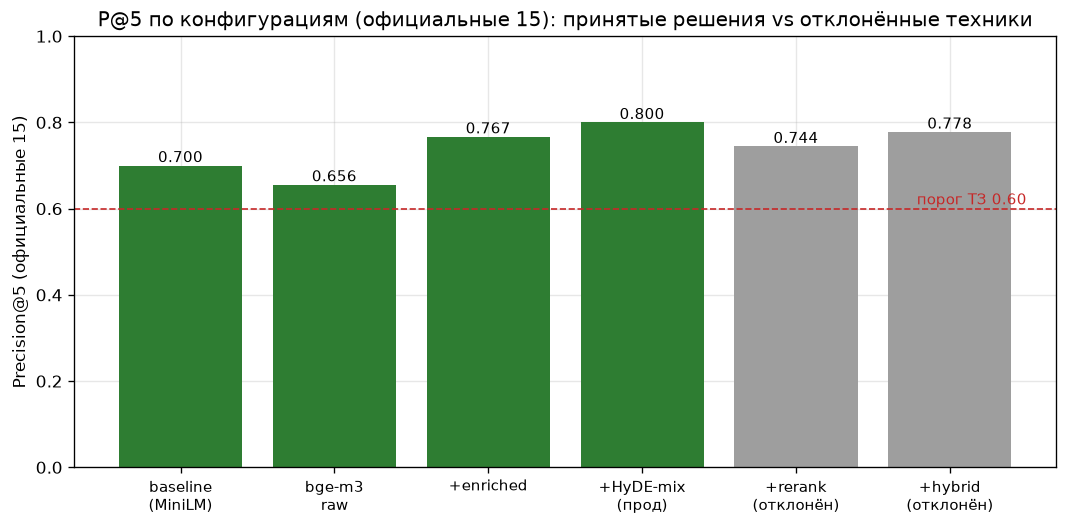

In [2]:
# Порядок: основная цепочка (зелёным) + отклонённые техники (серым).
# Headline-метрика — официальные 15 (p5_official15); combined-269 — только robustness (не здесь).
chain = ["baseline (MiniLM raw)", "bge-m3 raw", "bge-m3 + enriched",
         "bge-m3 + enriched + HyDE-mix"]
rejected = ["bge-m3 + enriched + rerank", "+ HyDE-mix + hybrid (w=0.2)"]
order = chain + [c for c in rejected if c in set(full["config"])]
d = full.set_index("config").loc[order].reset_index()
colors = ["#2e7d32" if c in chain else "#9e9e9e" for c in d["config"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(d)), d["p5_official15"], color=colors)
ax.axhline(0.60, ls="--", lw=1, color="#c62828")
ax.text(len(d) - 0.5, 0.61, "порог ТЗ 0.60", color="#c62828", ha="right", fontsize=9)
for b, v in zip(bars, d["p5_official15"]):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.008, f"{v:.3f}", ha="center", fontsize=9)
labels = ["baseline\n(MiniLM)", "bge-m3\nraw", "+enriched", "+HyDE-mix\n(прод)",
          "+rerank\n(отклонён)", "+hybrid\n(отклонён)"][:len(d)]
ax.set_xticks(range(len(d)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Precision@5 (официальные 15)")
ax.set_ylim(0, 1.0)
ax.set_title("P@5 по конфигурациям (официальные 15): принятые решения vs отклонённые техники")
fig.tight_layout()
fig.savefig(RESULTS / "fig_p5_by_config.png", bbox_inches="tight")
plt.show()

## Фигура 2 — RU vs EN по звеньям цепочки (официальные 15, человеческая разметка)

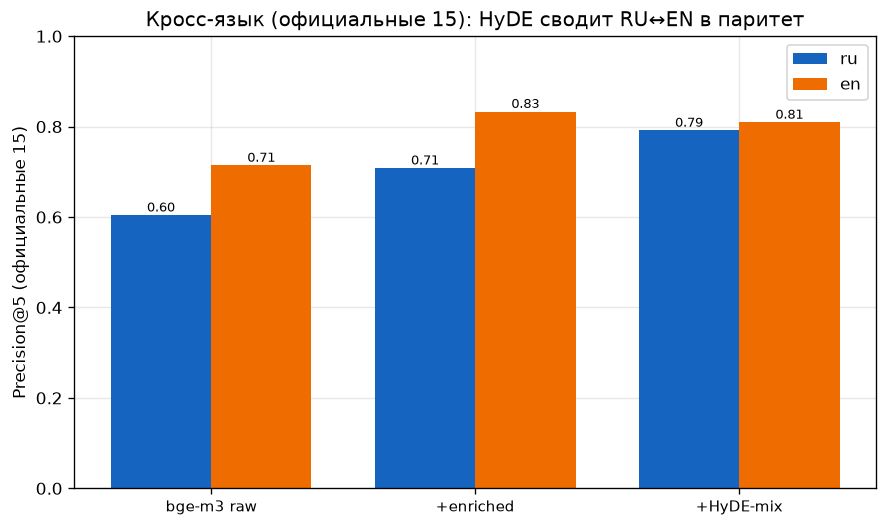

In [3]:
# Кросс-язык — ТОЛЬКО на человеческой разметке (официальные 15). Combined-269 НЕ используем:
# синтетика смещает EN (доказано per-subset bootstrap'ом). Числа из results/lang_official15.csv.
lang = pd.read_csv(RESULTS / "lang_official15.csv")
x = range(len(lang))
w = 0.38
fig, ax = plt.subplots(figsize=(7.5, 4.5))
b1 = ax.bar([i - w / 2 for i in x], lang["p5_ru"], w, label="ru", color="#1565c0")
b2 = ax.bar([i + w / 2 for i in x], lang["p5_en"], w, label="en", color="#ef6c00")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{b.get_height():.2f}", ha="center", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(lang["config"], fontsize=9)
ax.set_ylabel("Precision@5 (официальные 15)")
ax.set_ylim(0, 1.0)
ax.legend()
ax.set_title("Кросс-язык (официальные 15): HyDE сводит RU↔EN в паритет")
fig.tight_layout()
fig.savefig(RESULTS / "fig_ru_vs_en.png", bbox_inches="tight")
plt.show()

## Фигура 3 — Bake-off эмбеддеров: raw vs enriched (15 вопросов)

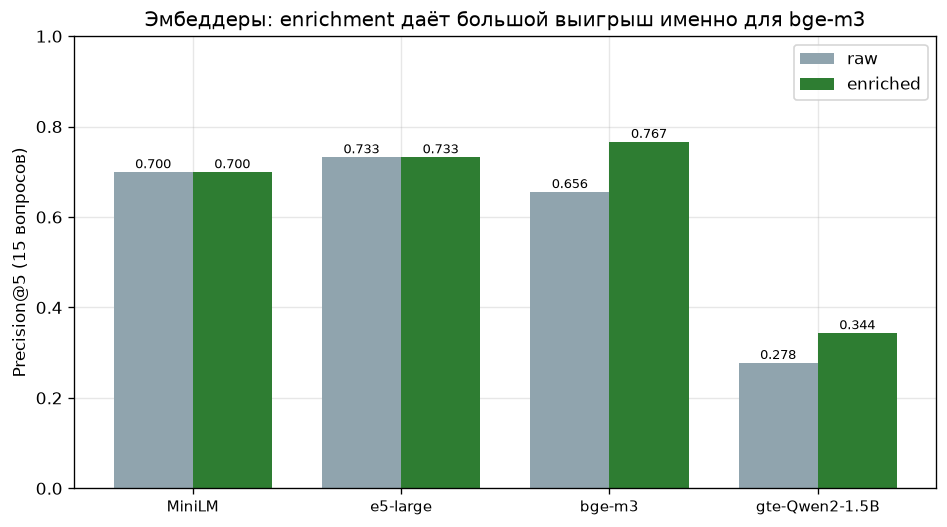

In [4]:
piv = models.pivot_table(index="model", columns="enriched", values="p5_total")
short = {"sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2": "MiniLM",
         "intfloat/multilingual-e5-large": "e5-large",
         "BAAI/bge-m3": "bge-m3",
         "Alibaba-NLP/gte-Qwen2-1.5B-instruct": "gte-Qwen2-1.5B"}
piv = piv.rename(index=short).loc[["MiniLM", "e5-large", "bge-m3", "gte-Qwen2-1.5B"]]
x = range(len(piv))
w = 0.38
fig, ax = plt.subplots(figsize=(8, 4.5))
b1 = ax.bar([i - w / 2 for i in x], piv[False], w, label="raw", color="#90a4ae")
b2 = ax.bar([i + w / 2 for i in x], piv[True], w, label="enriched", color="#2e7d32")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.008,
                f"{b.get_height():.3f}", ha="center", fontsize=8)
ax.set_xticks(list(x))
ax.set_xticklabels(piv.index, fontsize=9)
ax.set_ylabel("Precision@5 (15 вопросов)")
ax.set_ylim(0, 1.0)
ax.legend()
ax.set_title("Эмбеддеры: enrichment даёт большой выигрыш именно для bge-m3")
fig.tight_layout()
fig.savefig(RESULTS / "fig_model_bakeoff.png", bbox_inches="tight")
plt.show()